=== TASK 2.1: Loading California Housing Dataset ===
First 5 rows of dataset (Copy these for AI Prompt 2.1):
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20046  1.6812      25.0  4.192201   1.022284      1392.0  3.877437     36.06   
3024   2.5313      30.0  5.039384   1.193493      1565.0  2.679795     35.14   
15663  3.4801      52.0  3.977155   1.185877      1310.0  1.360332     37.80   
20484  5.7376      17.0  6.163636   1.020202      1705.0  3.444444     34.28   
9814   3.7250      34.0  5.492991   1.028037      1063.0  2.483645     36.62   

       Longitude  MedHouseVal  
20046    -119.01      0.47700  
3024     -119.46      0.45800  
15663    -122.44      5.00001  
20484    -118.72      2.18600  
9814     -121.93      2.78000  
=== TASK 2.2: Training Linear Regression ===
Linear Regression Mean 5-Fold R2 Score: 0.6457
--- Training Ridge Regression with Varying Alpha Values ---
Ridge Regression (alpha=   0.1) Mean 5-Fold R2 Score: 0.6457
Ridge

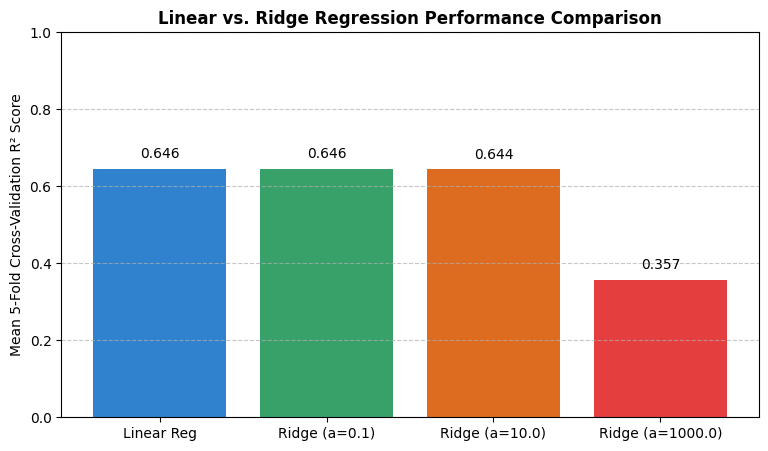

In [1]:
# ==============================================================================
# SC5002 - LAB ASSIGNMENT PART 2: LOW-CODE ML TEMPLATE
# Instructions: Run this cell sequentially in Google Colab.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
# --- TASK 2.1: DATASET SETUP ---
print("=== TASK 2.1: Loading California Housing Dataset ===")
housing = fetch_california_housing(as_frame=True)
df = housing.frame.sample(n=1000, random_state=42) # Sample 1000 records
print("First 5 rows of dataset (Copy these for AI Prompt 2.1):")
print(df.head())
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']
# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
# --- TASK 2.2: MODEL TRAINING & CROSS-VALIDATION ---
print("=== TASK 2.2: Training Linear Regression ===")
lin_reg = LinearRegression()
lin_scores = cross_val_score(lin_reg, X_train, y_train, cv=5, scoring='r2')
print(f"Linear Regression Mean 5-Fold R2 Score: {lin_scores.mean():.4f}")
# Ridge Regression Experiments
alphas = [0.1, 10.0, 1000.0]
ridge_results = {}
print("--- Training Ridge Regression with Varying Alpha Values ---")
for a in alphas:
  ridge = Ridge(alpha=a)
  scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
  ridge_results[a] = scores.mean()
  print (f"Ridge Regression (alpha={a:6.1f}) Mean 5-Fold R2 Score: {scores.mean():.4f}")
# --- TASK 2.3: VISUALIZATION ---
print("=== TASK 2.3: Generating Model Comparison Chart ===")
plt.figure(figsize=(9, 5))
models = ['Linear Reg'] + [f'Ridge (a={a})' for a in alphas]
scores = [lin_scores.mean()] + list(ridge_results.values())
bars = plt.bar(models, scores, color=['#3182ce', '#38a169', '#dd6b20', '#e53e3e'])
plt.ylabel('Mean 5-Fold Cross-Validation R² Score', fontsize=10)
plt.title('Linear vs. Ridge Regression Performance Comparison', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom')
plt.show()